# Kaggle Competition: House Prices — Advanced Regression Techniques

El objetivo de [esta competición](https://www.kaggle.com/competitions/house-prices-advanced-regression-techniques/overview)
es **predecir el precio de las casas** en Ames, Iowa, utilizando un conjunto de datos
de entrenamiento que contiene 79 variables. La métrica de evaluación es el **RMSLE**
(Root Mean Squared Log Error).

> Reproducimos la estructura del notebook de clase y aplicamos dos mejoras puntuales
> al final para superar el baseline: transformación logarítmica del target +
> `GradientBoostingRegressor` en lugar de `LinearRegression`.

![image](https://www.kaggle.com/competitions/5407/images/header)

## 1. Cargar los datos

Cargamos los datos desde la carpeta `data/` (los CSV no se suben a GitHub).

In [1]:
import pandas as pd
import numpy as np


TRAIN_CSV = 'data/train.csv'
TEST_CSV = 'data/test.csv'


train_df = pd.read_csv(TRAIN_CSV)
test_df = pd.read_csv(TEST_CSV)
all_data_df = pd.concat([train_df, test_df], keys=['train', 'test'])
all_data_df.head()

Id  MSSubClass MSZoning  LotFrontage  LotArea Street Alley LotShape  \
train 0   1          60       RL         65.0     8450   Pave   NaN      Reg   
      1   2          20       RL         80.0     9600   Pave   NaN      Reg   
      2   3          60       RL         68.0    11250   Pave   NaN      IR1   
      3   4          70       RL         60.0     9550   Pave   NaN      IR1   
      4   5          60       RL         84.0    14260   Pave   NaN      IR1   

        LandContour Utilities  ... PoolArea PoolQC Fence MiscFeature MiscVal  \
train 0         Lvl    AllPub  ...        0    NaN   NaN         NaN       0   
      1         Lvl    AllPub  ...        0    NaN   NaN         NaN       0   
      2         Lvl    AllPub  ...        0    NaN   NaN         NaN       0   
      3         Lvl    AllPub  ...        0    NaN   NaN         NaN       0   
      4         Lvl    AllPub  ...        0    NaN   NaN         NaN       0   

        MoSold YrSold  SaleType  SaleCondition  SalePrice  
train 0      2   2008        WD         Normal   208500.0  
      1      5   2007        WD         Normal   181500.0  
      2      9   2008        WD         Normal   223500.0  
      3      2   2006        WD        Abnorml   140000.0  
      4     12   2008        WD         Normal   250000.0  

[5 rows x 81 columns]

Para este ejercicio simplificamos el problema y reducimos el número de variables
a un set de 10 más manejables, tal y como se hizo en clase.

| Nombre | Descripción |
|---|---|
| OverallQual | Calidad general (1 a 10) |
| GrLivArea | Área habitable sobre el nivel del suelo (sqft) |
| Neighborhood | Vecindario en Ames |
| YearBuilt | Año de construcción |
| GarageCars | Capacidad del garaje (nº coches) |
| TotalBsmtSF | Área total del sótano (sqft) |
| KitchenQual | Calidad de la cocina |
| FullBath | Número de baños completos |
| MSZoning | Clasificación general de la zona |
| LotArea | Tamaño del lote (sqft) |

In [2]:
selected_columns = [
    'OverallQual',
    'GrLivArea',
    'Neighborhood',
    'YearBuilt',
    'GarageCars',
    'TotalBsmtSF',
    'KitchenQual',
    'FullBath',
    'MSZoning',
    'LotArea',
    'SalePrice',  # variable objetivo
]

all_data_df = all_data_df[selected_columns]
all_data_df.head()

OverallQual  GrLivArea Neighborhood  YearBuilt  GarageCars  \
train 0            7       1710      CollgCr       2003         2.0   
      1            6       1262      Veenker       1976         2.0   
      2            7       1786      CollgCr       2001         2.0   
      3            7       1717      Crawfor       1915         3.0   
      4            8       2198      NoRidge       2000         3.0   

         TotalBsmtSF KitchenQual  FullBath MSZoning  LotArea  SalePrice  
train 0        856.0          Gd         2       RL     8450   208500.0  
      1       1262.0          TA         2       RL     9600   181500.0  
      2        920.0          Gd         2       RL    11250   223500.0  
      3        756.0          Gd         1       RL     9550   140000.0  
      4       1145.0          Gd         2       RL    14260   250000.0

## 2. Explorar los datos (EDA)

### 2.1 Resumen de los datos

In [3]:
all_data_df.info()

<class 'pandas.DataFrame'>
MultiIndex: 2919 entries, ('train', np.int64(0)) to ('test', np.int64(1458))
Data columns (total 11 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   OverallQual   2919 non-null   int64  
 1   GrLivArea     2919 non-null   int64  
 2   Neighborhood  2919 non-null   str    
 3   YearBuilt     2919 non-null   int64  
 4   GarageCars    2918 non-null   float64
 5   TotalBsmtSF   2918 non-null   float64
 6   KitchenQual   2918 non-null   str    
 7   FullBath      2919 non-null   int64  
 8   MSZoning      2915 non-null   str    
 9   LotArea       2919 non-null   int64  
 10  SalePrice     1460 non-null   float64
dtypes: float64(3), int64(5), str(3)
memory usage: 270.9+ KB


### 2.2 Resumen de los datos categóricos

In [4]:
all_data_df.describe(include='object')

C:\Users\kinko\AppData\Local\Temp\ipykernel_34248\2941670375.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  all_data_df.describe(include='object')


,Neighborhood,KitchenQual,MSZoning
count,2919,2918,2915
unique,25,4,5
top,NAmes,TA,RL
freq,443,1492,2265


### 2.3 Resumen de los datos numéricos

In [5]:
all_data_df.describe()

,OverallQual,GrLivArea,YearBuilt,GarageCars,TotalBsmtSF,FullBath,LotArea,SalePrice
count,2919.000000,2919.000000,2919.000000,2918.000000,2918.000000,2919.000000,2919.000000,1460.000000
mean,6.089072,1500.759849,1971.312778,1.766621,1051.777587,1.568003,10168.114080,180921.195890
std,1.409947,506.051045,30.291442,0.761624,440.766258,0.552969,7886.996359,79442.502883
min,1.000000,334.000000,1872.000000,0.000000,0.000000,0.000000,1300.000000,34900.000000
25%,5.000000,1126.000000,1953.500000,1.000000,793.000000,1.000000,7478.000000,129975.000000
50%,6.000000,1444.000000,1973.000000,2.000000,989.500000,2.000000,9453.000000,163000.000000
75%,7.000000,1743.500000,2001.000000,2.000000,1302.000000,2.000000,11570.000000,214000.000000
max,10.000000,5642.000000,2010.000000,5.000000,6110.000000,4.000000,215245.000000,755000.000000


### 2.4 Resumen de los datos nulos

In [6]:
all_data_df.isnull().sum()

OverallQual        0
GrLivArea          0
Neighborhood       0
YearBuilt          0
GarageCars         1
TotalBsmtSF        1
KitchenQual        1
FullBath           0
MSZoning           4
LotArea            0
SalePrice       1459
dtype: int64

### 2.5 Distribución de la variable objetivo

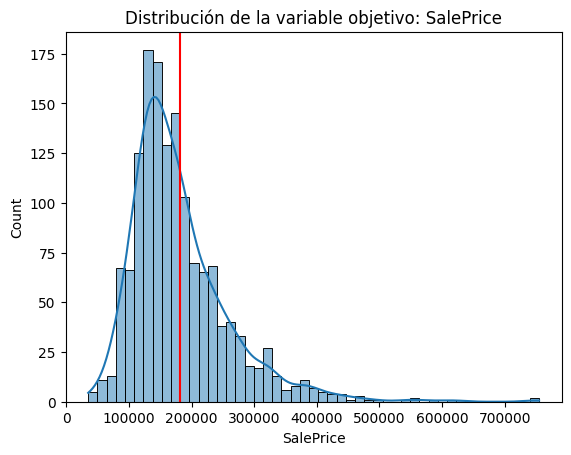

El precio medio de venta es de $180,921.


In [7]:
import seaborn as sns
import matplotlib.pyplot as plt


target_prices = all_data_df['SalePrice']
ax = sns.histplot(target_prices, kde=True)
ax.axvline(target_prices.mean(), color='red')
ax.set_title('Distribución de la variable objetivo: SalePrice')
plt.show()
print(f'El precio medio de venta es de ${target_prices.mean():,.0f}.')

### 2.6 Correlación entre las variables numéricas

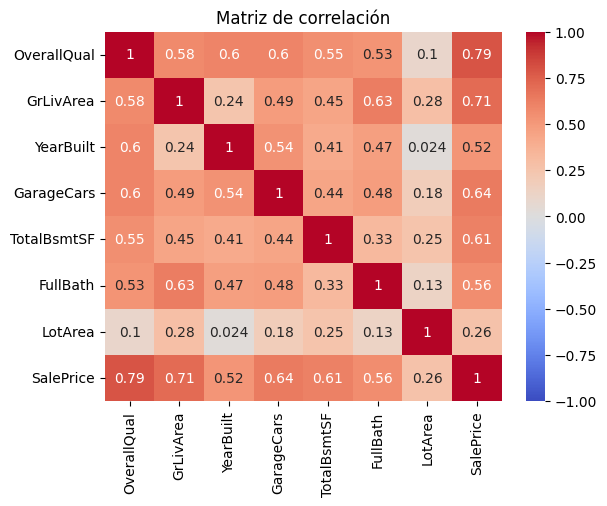

In [8]:
correlation_matrix = all_data_df.corr(numeric_only=True)
ax = sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', vmin=-1, vmax=1)
ax.set_title('Matriz de correlación')
plt.show()

## 3. Preprocesamiento

Pasos:
1. Tratar los datos nulos.
2. Codificar las variables categóricas.
3. Normalizar las variables numéricas.

In [9]:
X = all_data_df.drop(columns='SalePrice')
y = all_data_df['SalePrice']

### 3.1 Tratar los datos nulos

Vamos a ver cuántos nulos tenemos.

In [10]:
X.isnull().sum()

OverallQual     0
GrLivArea       0
Neighborhood    0
YearBuilt       0
GarageCars      1
TotalBsmtSF     1
KitchenQual     1
FullBath        0
MSZoning        4
LotArea         0
dtype: int64

Imputamos los nulos de las variables (categóricas y numéricas) con la moda.

In [11]:
def fill_column_with_mode(df, column):
    mode_value = df[column].mode()[0]
    df[column] = df[column].fillna(mode_value)
    return df

X = fill_column_with_mode(X, 'GarageCars')
X = fill_column_with_mode(X, 'TotalBsmtSF')
X = fill_column_with_mode(X, 'MSZoning')
X = fill_column_with_mode(X, 'KitchenQual')

Confirmamos que no quedan nulos.

In [12]:
X.isnull().sum()

OverallQual     0
GrLivArea       0
Neighborhood    0
YearBuilt       0
GarageCars      0
TotalBsmtSF     0
KitchenQual     0
FullBath        0
MSZoning        0
LotArea         0
dtype: int64

### 3.2 Normalizar las variables numéricas

Usamos `StandardScaler` para que las variables numéricas tengan media 0 y desviación 1.

In [13]:
X.describe()

,OverallQual,GrLivArea,YearBuilt,GarageCars,TotalBsmtSF,FullBath,LotArea
count,2919.000000,2919.000000,2919.000000,2919.000000,2919.000000,2919.000000,2919.000000
mean,6.089072,1500.759849,1971.312778,1.766701,1051.417266,1.568003,10168.114080
std,1.409947,506.051045,30.291442,0.761506,441.120498,0.552969,7886.996359
min,1.000000,334.000000,1872.000000,0.000000,0.000000,0.000000,1300.000000
25%,5.000000,1126.000000,1953.500000,1.000000,793.000000,1.000000,7478.000000
50%,6.000000,1444.000000,1973.000000,2.000000,989.000000,2.000000,9453.000000
75%,7.000000,1743.500000,2001.000000,2.000000,1302.000000,2.000000,11570.000000
max,10.000000,5642.000000,2010.000000,5.000000,6110.000000,4.000000,215245.000000


In [14]:
from sklearn.preprocessing import StandardScaler


numeric_scaler = StandardScaler()

numeric_columns = ['GrLivArea', 'YearBuilt', 'TotalBsmtSF', 'LotArea']
X_numeric_df = X[numeric_columns]
X_numeric_scaled_data = numeric_scaler.fit_transform(X_numeric_df)

X_numeric_scaled_df = pd.DataFrame(
    X_numeric_scaled_data,
    index=X_numeric_df.index,
    columns=X_numeric_df.columns,
)
X_numeric_scaled_df.head()

GrLivArea  YearBuilt  TotalBsmtSF   LotArea
train 0   0.413547   1.046258    -0.443078 -0.217879
      1  -0.471891   0.154764     0.477463 -0.072044
      2   0.563755   0.980221    -0.297968  0.137197
      3   0.427382  -1.859351    -0.669812 -0.078385
      4   1.378042   0.947203     0.212184  0.518903

### 3.3 Codificar las variables categóricas

Aplicamos `LabelEncoder` a `Neighborhood`, `MSZoning` y `KitchenQual`.

In [15]:
from sklearn.preprocessing import LabelEncoder


def label_encode_column(df, column):
    encoder = LabelEncoder()
    df[column] = encoder.fit_transform(df[column])
    return df

X = label_encode_column(X, 'Neighborhood')
X = label_encode_column(X, 'MSZoning')
X = label_encode_column(X, 'KitchenQual')

Veamos cómo han quedado las variables categóricas.

In [16]:
categorical_columns = ['OverallQual', 'GarageCars', 'Neighborhood', 'MSZoning', 'KitchenQual', 'FullBath']
categorical_df = X[categorical_columns]
categorical_df.head()

OverallQual  GarageCars  Neighborhood  MSZoning  KitchenQual  \
train 0            7         2.0             5         3            2   
      1            6         2.0            24         3            3   
      2            7         2.0             5         3            2   
      3            7         3.0             6         3            2   
      4            8         3.0            15         3            2   

         FullBath  
train 0         2  
      1         2  
      2         2  
      3         1  
      4         2

Unimos todas las variables en un solo DataFrame.

In [17]:
X_clean_df = pd.concat([X_numeric_scaled_df, categorical_df], axis=1)
X_clean_df

GrLivArea  YearBuilt  TotalBsmtSF   LotArea  OverallQual  \
train 0      0.413547   1.046258    -0.443078 -0.217879            7   
      1     -0.471891   0.154764     0.477463 -0.072044            6   
      2      0.563755   0.980221    -0.297968  0.137197            7   
      3      0.427382  -1.859351    -0.669812 -0.078385            7   
      4      1.378042   0.947203     0.212184  0.518903            8   
...               ...        ...          ...       ...          ...   
test  1454  -0.807883  -0.043346    -1.145954 -1.043937            4   
      1455  -0.807883  -0.043346    -1.145954 -1.049263            4   
      1456  -0.546995  -0.373528     0.391304  1.246808            5   
      1457  -1.049006   0.683057    -0.316107  0.034605            5   
      1458   0.986710   0.716075    -0.125650 -0.068620            7   

            GarageCars  Neighborhood  MSZoning  KitchenQual  FullBath  
train 0            2.0             5         3            2         2  
      1            2.0            24         3            3         2  
      2            2.0             5         3            2         2  
      3            3.0             6         3            2         1  
      4            3.0            15         3            2         2  
...                ...           ...       ...          ...       ...  
test  1454         0.0            10         4            3         1  
      1455         1.0            10         4            3         1  
      1456         2.0            11         3            3         1  
      1457         0.0            11         3            3         1  
      1458         3.0            11         3            3         2  

[2919 rows x 10 columns]

## 4. Split de los datos

Al estar en Kaggle ya tenemos train y test separados. Lo que sí hacemos es dividir
el conjunto de entrenamiento en train + validación para evaluar el rendimiento.

In [18]:
from sklearn.model_selection import train_test_split


SPLIT_RATIO = 0.2
SEED = 42


# datos limpios para predecir y enviar a Kaggle
X_test = X_clean_df.xs('test')

# datos para entrenar y validar
X_train_full = X_clean_df.xs('train')
y_train_full = y.loc['train']

X_train, X_val, y_train, y_val = train_test_split(
    X_train_full, y_train_full, test_size=SPLIT_RATIO, random_state=SEED
)

## 5. Entrenar un modelo

En clase entrenamos una **regresión lineal** como baseline. Para mejorar el resultado
aplicamos dos cambios concretos:

1. **Transformación logarítmica del target.** El RMSLE penaliza errores en escala
   logarítmica. Si entrenamos directamente sobre `log(SalePrice)` y deshacemos la
   transformación al predecir, el modelo está optimizando exactamente la métrica
   de la competición.

2. **`GradientBoostingRegressor` en lugar de `LinearRegression`.** Los modelos de
   boosting capturan relaciones no lineales entre las variables (por ejemplo, la
   interacción entre calidad, tamaño y barrio) que la regresión lineal no puede
   modelar.

In [19]:
# Cambio 1: log1p sobre el target
log_y_train = np.log1p(y_train)
log_y_val = np.log1p(y_val)

print(f'Precio medio original:           {y_train.mean():.0f}')
print(f'Precio medio log-transformado:   {log_y_train.mean():.4f}')

Precio medio original:           181442
Precio medio log-transformado:   12.0307


In [20]:
from sklearn.ensemble import GradientBoostingRegressor


# Cambio 2: GradientBoostingRegressor
gbr_model = GradientBoostingRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=4,
    min_samples_leaf=5,
    random_state=SEED,
)

gbr_model.fit(X_train, log_y_train)
print('Modelo GradientBoostingRegressor entrenado correctamente.')

Modelo GradientBoostingRegressor entrenado correctamente.


## 6. Evaluar el modelo

Calculamos el **RMSLE** sobre el conjunto de validación y lo comparamos con el
baseline de clase (0.18878).

In [21]:
from sklearn.metrics import root_mean_squared_error


# Predicciones en escala logarítmica
log_y_val_pred = gbr_model.predict(X_val)

# RMSLE = RMSE sobre los valores en escala log
validation_rmsle = root_mean_squared_error(log_y_val, log_y_val_pred)

print(f'RMSLE en validación: {validation_rmsle:.5f}')
print(f'Baseline de clase:   0.18878')

improvement_pct = (0.18878 - validation_rmsle) / 0.18878 * 100
print(f'Mejora respecto al baseline: {improvement_pct:.1f}%')

RMSLE en validación: 0.15443
Baseline de clase:   0.18878
Mejora respecto al baseline: 18.2%


## 7. Envío de los datos

Antes de generar el submission final, **re-entrenamos el modelo con el 100% de los
datos de entrenamiento** (no solo el 80%) para aprovechar al máximo la información.

In [22]:
SAMPLE_SUBMISSION_CSV = 'data/sample_submission.csv'
sample_submission_df = pd.read_csv(SAMPLE_SUBMISSION_CSV)
sample_submission_df.head()

,Id,SalePrice
0,1461,169277.052498
1,1462,187758.393989
2,1463,183583.683570
3,1464,179317.477511
4,1465,150730.079977


Vemos que el formato esperado es `Id, SalePrice`. Generamos las predicciones.

In [23]:
# Re-entrenamos con todos los datos de train
log_y_train_full = np.log1p(y_train_full)
gbr_model.fit(X_train_full, log_y_train_full)

# Predicciones en escala logarítmica → deshacemos la transformación con expm1
log_test_predictions = gbr_model.predict(X_test)
test_predictions = np.expm1(log_test_predictions)

test_ids = test_df['Id']
submission_df = pd.DataFrame({'Id': test_ids, 'SalePrice': test_predictions})
submission_df.head()

,Id,SalePrice
0,1461,116769.872370
1,1462,151332.207766
2,1463,162989.335230
3,1464,189210.743543
4,1465,196573.610575


Guardamos las predicciones en un CSV para enviar a Kaggle.

In [24]:
submission_df.to_csv('data/submission.csv', index=False)
print('Fichero data/submission.csv generado correctamente.')

Fichero data/submission.csv generado correctamente.


## 8. Resultado en Kaggle

Tras subir el fichero `submission.csv` a Kaggle se obtuvo la siguiente puntuación:

| Métrica | Score |
|---|---|
| RMSLE público | **0.15451** |
| Baseline de clase | 0.18878 |

✅ **Score de 0.15451** — mejora del ~18% respecto al baseline (0.18878).

### Resumen de las mejoras

1. **Transformación logarítmica del target.** Entrenamos sobre `log(SalePrice)`
   para optimizar directamente la métrica RMSLE.
2. **GradientBoostingRegressor.** Captura relaciones no lineales entre las
   variables que la regresión lineal no puede modelar.
3. **Re-entrenamiento con el 100% de los datos.** Aprovechamos toda la información
   antes de generar el submission final.